<h1>Aqui se entrenara el modelo del cnn para detectar a 1 usuario y a los posibles intrusos</h1>

Importamos todo 

In [12]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

Configuramos las rutas

In [57]:
BASE_DIR = Path(r"D:\\Aplicaciones multiplataforma\\002 - RelojChecador IA\\Training")


TRAIN_DIR = BASE_DIR / "DataSet" / "Train"
VAL_DIR = BASE_DIR / "DataSet" / "Validation"

MODEL_OUT_DIR = BASE_DIR / "Notebooks" / "Model"
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)

LABELS_PATH = MODEL_OUT_DIR / "labels.json"

WEIGHTS_PATH = MODEL_OUT_DIR / "best_model.weights.h5"
KERAS_MODEL_PATH = MODEL_OUT_DIR / "trained_model.keras"
H5_MODEL_PATH = MODEL_OUT_DIR / "trained_model.h5"

IMG_SIZE = 128
BATCH_SIZE = 16
SEED = 47

Cargamos el data set

In [58]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Clases detectadas:", class_names)
print("Número de clases:", num_classes)

Found 1269 files belonging to 7 classes.
Found 503 files belonging to 7 classes.
Clases detectadas: ['CotoSet', 'DanielSet', 'Intruso', 'Lizbeth Castañeda Rivas', 'NaomiSet3', 'SantosSet', 'angelito']
Número de clases: 7


creamos un arreglo para asignar los nombres

In [59]:
labels = {str(i): class_name for i, class_name in enumerate(class_names)}

with open(LABELS_PATH, "w", encoding="utf-8") as f:
    json.dump(labels, f, indent=4, ensure_ascii=False)

labels

{'0': 'CotoSet',
 '1': 'DanielSet',
 '2': 'Intruso',
 '3': 'Lizbeth Castañeda Rivas',
 '4': 'NaomiSet3',
 '5': 'SantosSet',
 '6': 'angelito'}

optimizaremos la carga del dataset

In [60]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

calculamos los pesos por clase

In [61]:
def count_images_by_class(directory, class_names):
    counts = {}
    for class_name in class_names:
        class_dir = Path(directory) / class_name
        image_files = (
            list(class_dir.glob("*.jpg")) +
            list(class_dir.glob("*.jpeg")) +
            list(class_dir.glob("*.png"))
        )
        counts[class_name] = len(image_files)
    return counts

train_counts = count_images_by_class(TRAIN_DIR, class_names)
print("Conteo entrenamiento:", train_counts)

total = sum(train_counts.values())

class_weight = {}

for i, class_name in enumerate(class_names):
    class_count = train_counts[class_name]
    class_weight[i] = total / (num_classes * class_count)

print("Class weights:", class_weight)

Conteo entrenamiento: {'CotoSet': 196, 'DanielSet': 146, 'Intruso': 120, 'Lizbeth Castañeda Rivas': 123, 'NaomiSet3': 218, 'SantosSet': 246, 'angelito': 220}
Class weights: {0: 0.9249271137026239, 1: 1.241682974559687, 2: 1.5107142857142857, 3: 1.4738675958188154, 4: 0.8315858453473133, 5: 0.7369337979094077, 6: 0.824025974025974}


Empezamos a configurar

In [62]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.10),
], name="data_augmentation")

In [63]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,215 (1.61 MB)

 Trainable params: 422,215 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [64]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [65]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=str(WEIGHTS_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
]

In [66]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks#,
#    class_weight=class_weight
)

Epoch 1/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.1819 - loss: 1.9169
Epoch 1: val_loss improved from None to 1.92028, saving model to D:\Aplicaciones multiplataforma\002 - RelojChecador IA\Training\Notebooks\Model\best_model.weights.h5

Epoch 1: finished saving model to D:\Aplicaciones multiplataforma\002 - RelojChecador IA\Training\Notebooks\Model\best_model.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 317ms/step - accuracy: 0.1915 - loss: 1.9108 - val_accuracy: 0.1789 - val_loss: 1.9203 - learning_rate: 1.0000e-04
Epoch 2/40
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.1859 - loss: 1.8885
Epoch 2: val_loss improved from 1.92028 to 1.86223, saving model to D:\Aplicaciones multiplataforma\002 - RelojChecador IA\Training\Notebooks\Model\best_model.weights.h5

Epoch 2: finished saving model to D:\Aplicaciones multiplataforma\002 - RelojChecador IA\Training\Notebooks\Model\best_model.weights.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 311ms/step - accuracy: 0.1891 - loss: 1.

In [67]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def evaluar_predicciones(ds, nombre):
    y_true = []
    y_pred = []

    for images, labels_batch in ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels_batch.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print(f"\n===== {nombre} =====")
    print("Predicciones por clase:")

    unique, counts = np.unique(y_pred, return_counts=True)
    for idx, count in zip(unique, counts):
        print(class_names[idx], ":", count)

    print("\nMatriz de confusión:")
    print(confusion_matrix(y_true, y_pred))

    print("\nReporte:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

evaluar_predicciones(train_ds, "TRAIN")
evaluar_predicciones(val_ds, "VALIDATION")


===== TRAIN =====
Predicciones por clase:
CotoSet : 222
DanielSet : 130
Intruso : 121
Lizbeth Castañeda Rivas : 124
NaomiSet3 : 228
SantosSet : 231
angelito : 213

Matriz de confusión:
[[195   0   1   0   0   0   0]
 [  2 127   0   0   1  16   0]
 [  1   1 111   2   0   5   0]
 [  0   0   1 120   1   1   0]
 [  0   0   0   0 217   1   0]
 [ 24   2   8   1   4 205   2]
 [  0   0   0   1   5   3 211]]

Reporte:
                         precision    recall  f1-score   support

                CotoSet       0.88      0.99      0.93       196
              DanielSet       0.98      0.87      0.92       146
                Intruso       0.92      0.93      0.92       120
Lizbeth Castañeda Rivas       0.97      0.98      0.97       123
              NaomiSet3       0.95      1.00      0.97       218
              SantosSet       0.89      0.83      0.86       246
               angelito       0.99      0.96      0.97       220

               accuracy                           0.93      1269

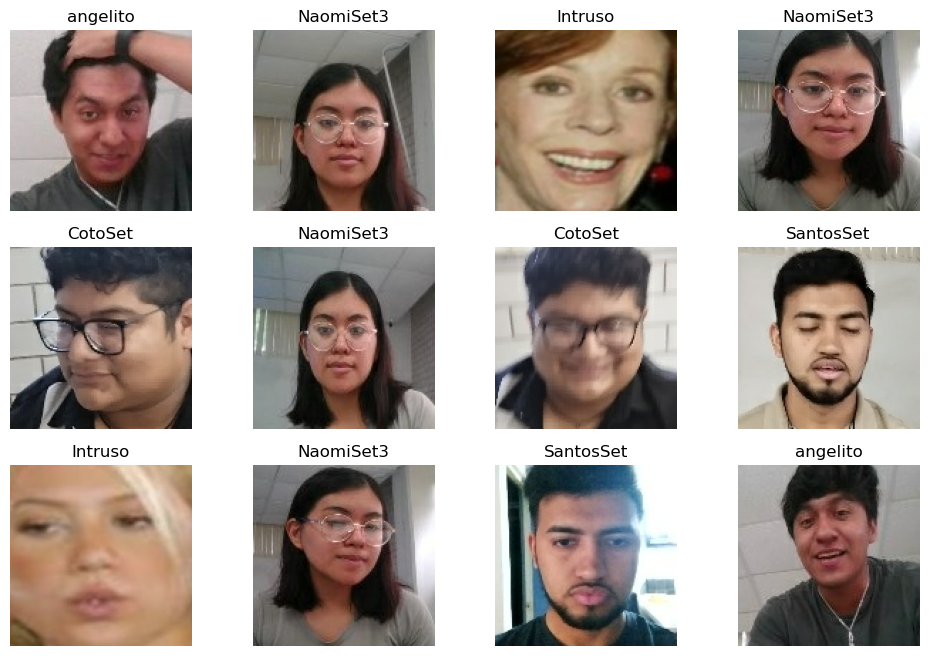

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for images, labels_batch in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

plt.show()

Graficamos

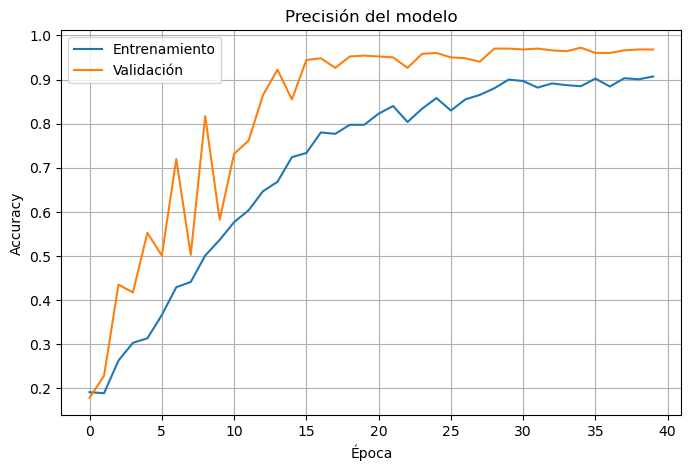

In [69]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Validación")
plt.title("Precisión del modelo")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

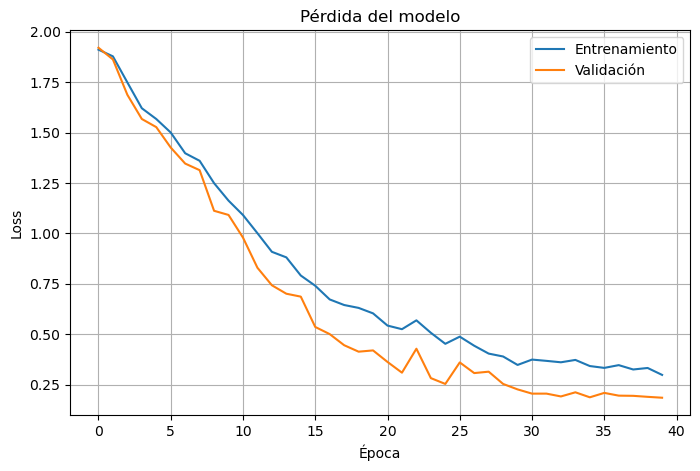

In [70]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")
plt.title("Pérdida del modelo")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Evaluamos

In [71]:
val_loss, val_accuracy = model.evaluate(val_ds)

print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.9682 - loss: 0.1853
Validation loss: 0.1853
Validation accuracy: 0.9682


Guardamos el modelo final

In [72]:
# Cargar los mejores pesos guardados durante entrenamiento
if WEIGHTS_PATH.exists():
    model.load_weights(str(WEIGHTS_PATH))
    print("Mejores pesos cargados desde:", WEIGHTS_PATH)
else:
    print("No se encontró archivo de pesos. Se guardará el modelo actual.")

# Guardar en formato moderno Keras
model.save(str(KERAS_MODEL_PATH))

print("Modelo .keras guardado en:", KERAS_MODEL_PATH)
print("Etiquetas guardadas en:", LABELS_PATH)

Mejores pesos cargados desde: D:\Aplicaciones multiplataforma\002 - RelojChecador IA\Training\Notebooks\Model\best_model.weights.h5
Modelo .keras guardado en: D:\Aplicaciones multiplataforma\002 - RelojChecador IA\Training\Notebooks\Model\trained_model.keras
Etiquetas guardadas en: D:\Aplicaciones multiplataforma\002 - RelojChecador IA\Training\Notebooks\Model\labels.json


<h1>Predicciones codigo axiliar</h1>

In [73]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
import tensorflow as tf

# Si el modelo no está cargado en memoria, lo cargamos desde el .keras
if "model" not in globals():
    model = tf.keras.models.load_model(str(KERAS_MODEL_PATH), compile=False)
    print("Modelo cargado desde:", KERAS_MODEL_PATH)
else:
    print("Usando modelo ya cargado en memoria.")

# Cargar labels
with open(LABELS_PATH, "r", encoding="utf-8") as f:
    labels = json.load(f)

print("Labels:", labels)

# Detector Haar Cascade de OpenCV
cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_detector = cv2.CascadeClassifier(cascade_path)

if face_detector.empty():
    raise Exception("No se pudo cargar el detector Haar Cascade.")

Usando modelo ya cargado en memoria.
Labels: {'0': 'CotoSet', '1': 'DanielSet', '2': 'Intruso', '3': 'Lizbeth Castañeda Rivas', '4': 'NaomiSet3', '5': 'SantosSet', '6': 'angelito'}


In [74]:
def crop_largest_face(image_path, img_size=128, margin=0.25):
    image_path = Path(image_path)
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        raise ValueError(f"No se pudo leer la imagen: {image_path}")

    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60, 60)
    )

    if len(faces) == 0:
        return None, image_bgr, "sin_rostro"

    # Tomar el rostro más grande
    x, y, w, h = max(faces, key=lambda face: face[2] * face[3])

    margin_x = int(w * margin)
    margin_y = int(h * margin)

    x1 = max(0, x - margin_x)
    y1 = max(0, y - margin_y)
    x2 = min(image_bgr.shape[1], x + w + margin_x)
    y2 = min(image_bgr.shape[0], y + h + margin_y)

    face_bgr = image_bgr[y1:y2, x1:x2]

    if face_bgr.size == 0:
        return None, image_bgr, "recorte_vacio"

    face_bgr = cv2.resize(face_bgr, (img_size, img_size))

    return face_bgr, image_bgr, "ok"

In [75]:
def predict_image(image_path, threshold=0.70):
    face_bgr, original_bgr, status = crop_largest_face(
        image_path=image_path,
        img_size=IMG_SIZE,
        margin=0.25
    )

    if status != "ok":
        print("No se pudo detectar rostro.")
        print("Estado:", status)

        original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(5, 5))
        plt.imshow(original_rgb)
        plt.title("Imagen original sin rostro detectado")
        plt.axis("off")
        plt.show()

        return None

    # Convertir BGR a RGB porque el entrenamiento usó imágenes en RGB
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)

    # Crear batch: (1, 128, 128, 3)
    input_img = np.expand_dims(face_rgb, axis=0)

    # NO dividir entre 255 aquí porque tu modelo ya tiene layers.Rescaling(1./255)
    predictions = model.predict(input_img, verbose=0)[0]

    predicted_index = int(np.argmax(predictions))
    confidence = float(predictions[predicted_index])
    predicted_label = labels[str(predicted_index)]

    if predicted_label.lower() != "intruso" and confidence >= threshold:
        result = "Usuario reconocido"
        is_intruder = False
    else:
        result = "Intruso / desconocido"
        is_intruder = True

    print("Imagen:", image_path)
    print("Predicciones:", predictions)
    print("Clase predicha:", predicted_label)
    print("Confianza:", round(confidence * 100, 2), "%")
    print("Resultado:", result)
    print("¿Es intruso?:", is_intruder)

    plt.figure(figsize=(5, 5))
    plt.imshow(face_rgb)
    plt.title(f"{predicted_label} - {confidence:.2%}")
    plt.axis("off")
    plt.show()

    return {
        "predicted_index": predicted_index,
        "predicted_label": predicted_label,
        "confidence": confidence,
        "is_intruder": is_intruder,
        "result": result
    }

In [76]:

listaDeResultados = []

Imagen: C:\Users\Santos\Pictures\Camera Roll\val_19.jpg
Predicciones: [3.3539201e-03 6.6538661e-05 7.3775315e-01 1.2312573e-01 5.4745227e-02
 8.0146633e-02 8.0885424e-04]
Clase predicha: Intruso
Confianza: 73.78 %
Resultado: Intruso / desconocido
¿Es intruso?: True


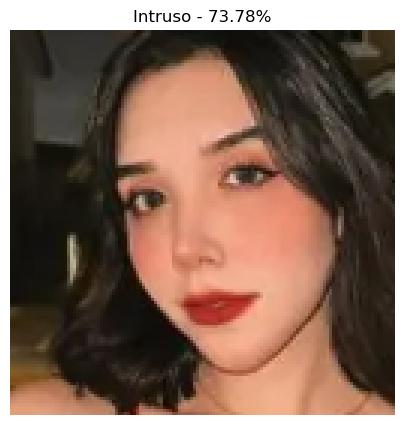

In [96]:
TEST_IMAGE = r"C:\Users\Santos\Pictures\Camera Roll\val_19.jpg"
#TEST_IMAGE = r"D:\Aplicaciones multiplataforma\002 - RelojChecador IA\Training\DataSet\Validation\SantosSet\Santos_0207.jpg"

resultado = predict_image(TEST_IMAGE, threshold=0.70)
listaDeResultados.append(resultado)

In [78]:
nklj

NameError: name 'nklj' is not defined

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import shutil
import tensorflow as tf
import matplotlib.pyplot as plt

# Carpeta donde se guardarán las imágenes mal clasificadas
ERRORES_DIR = Path("Model/errores_prediccion")
ERRORES_DIR.mkdir(parents=True, exist_ok=True)

# Crear dataset de validación SIN shuffle para conservar el orden de archivos
val_eval_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    class_names=class_names,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Obtener rutas de archivos
file_paths = val_eval_ds.file_paths

# Obtener predicciones
predictions = model.predict(val_eval_ds, verbose=1)

# Obtener etiquetas reales
y_true = []
for _, labels_batch in val_eval_ds:
    y_true.extend(labels_batch.numpy())

y_true = np.array(y_true)
y_pred = np.argmax(predictions, axis=1)

errores = []

for i, (real_idx, pred_idx) in enumerate(zip(y_true, y_pred)):
    if real_idx != pred_idx:
        probs = predictions[i]
        sorted_indices = np.argsort(probs)[::-1]

        top1_idx = int(sorted_indices[0])
        top2_idx = int(sorted_indices[1])

        confianza = float(probs[top1_idx])
        segunda_confianza = float(probs[top2_idx])
        margen = confianza - segunda_confianza

        archivo = Path(file_paths[i])
        clase_real = class_names[int(real_idx)]
        clase_predicha = class_names[int(pred_idx)]
        segunda_opcion = class_names[top2_idx]

        nuevo_nombre = (
            f"REAL_{clase_real}__PRED_{clase_predicha}"
            f"__CONF_{confianza:.2f}__{archivo.name}"
        )

        # Limpiar caracteres raros por nombres largos o acentos
        nuevo_nombre = nuevo_nombre.replace(" ", "_").replace("/", "_").replace("\\", "_")

        destino = ERRORES_DIR / nuevo_nombre
        shutil.copy2(archivo, destino)

        errores.append({
            "archivo": str(archivo),
            "real": clase_real,
            "predicho": clase_predicha,
            "confianza": round(confianza * 100, 2),
            "segunda_opcion": segunda_opcion,
            "segunda_confianza": round(segunda_confianza * 100, 2),
            "margen": round(margen * 100, 2),
            "copia_error": str(destino)
        })

df_errores = pd.DataFrame(errores)

print("Total imágenes validación:", len(file_paths))
print("Errores encontrados:", len(df_errores))
print("Accuracy calculada:", round((1 - len(df_errores) / len(file_paths)) * 100, 2), "%")
print("Carpeta de errores:", ERRORES_DIR.resolve())

df_errores

Found 395 files belonging to 7 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step
Total imágenes validación: 395
Errores encontrados: 44
Accuracy calculada: 88.86 %
Carpeta de errores: D:\Aplicaciones multiplataforma\002 - RelojChecador IA\Training\Notebooks\Model\errores_prediccion


,archivo,real,predicho,confianza,segunda_opcion,segunda_confianza,margen,copia_error
0,D:\Aplicaciones multiplataforma\002 - RelojChe...,CotoSet,Jesus Guzman,46.17,CotoSet,44.10,2.07,Model\errores_prediccion\REAL_CotoSet__PRED_Je...
1,D:\Aplicaciones multiplataforma\002 - RelojChe...,DanielSet,SantosSet,36.11,DanielSet,22.82,13.29,Model\errores_prediccion\REAL_DanielSet__PRED_...
2,D:\Aplicaciones multiplataforma\002 - RelojChe...,DanielSet,SantosSet,36.20,DanielSet,23.77,12.43,Model\errores_prediccion\REAL_DanielSet__PRED_...
3,D:\Aplicaciones multiplataforma\002 - RelojChe...,DanielSet,SantosSet,30.75,NaomiSet,30.27,0.48,Model\errores_prediccion\REAL_DanielSet__PRED_...
4,D:\Aplicaciones multiplataforma\002 - RelojChe...,DanielSet,SantosSet,36.92,DanielSet,23.20,13.72,Model\errores_prediccion\REAL_DanielSet__PRED_...
5,D:\Aplicaciones multiplataforma\002 - RelojChe...,DanielSet,SantosSet,42.34,DanielSet,20.87,21.47,Model\errores_prediccion\REAL_DanielSet__PRED_...
6,D:\Aplicaciones multiplataforma\002 - RelojChe...,DanielSet,CotoSet,39.75,SantosSet,24.61,15.14,Model\errores_prediccion\REAL_DanielSet__PRED_...
7,D:\Aplicaciones multiplataforma\002 - RelojChe...,DanielSet,SantosSet,39.89,DanielSet,34.41,5.48,Model\errores_prediccion\REAL_DanielSet__PRED_...
8,D:\Aplicaciones multiplataforma\002 - RelojChe...,DanielSet,SantosSet,29.88,NaomiSet,28.31,1.57,Model\errores_prediccion\REAL_DanielSet__PRED_...
9,D:\Aplicaciones multiplataforma\002 - RelojChe...,DanielSet,SantosSet,35.20,DanielSet,35.16,0.04,Model\errores_prediccion\REAL_DanielSet__PRED_...


In [ ]:
listaDeResultados

[{'predicted_index': 6,
  'predicted_label': 'SantosSet',
  'confidence': 0.4356183111667633,
  'is_intruder': True,
  'result': 'Intruso / desconocido'}]